In [2]:
import geopandas as gpd
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point
from shapely.geometry.polygon import Polygon
from matplotlib.colors import ListedColormap

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
divipola_df=pd.read_csv('/content/drive/MyDrive/eco2026/Divipola.csv')
divipola_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 7 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   Código Departamento                              1122 non-null   int64 
 1   Nombre Departamento                              1122 non-null   object
 2   Código Municipio                                 1122 non-null   int64 
 3   Nombre Municipio                                 1122 non-null   object
 4   Tipo: Municipio / Isla / Área no municipalizada  1122 non-null   object
 5   longitud                                         1122 non-null   object
 6   Latitud                                          1122 non-null   object
dtypes: int64(2), object(5)
memory usage: 61.5+ KB


In [4]:
divipola_df_renamed = divipola_df.rename(columns={
    'Código Departamento': 'cod_departamento',
    'Código Municipio': 'cod_municipio',
    'Nombre Departamento': 'nombre_depto',
    'Nombre Municipio': 'nombre_mpio'
})
divipola_df_renamed.to_csv('/content/drive/MyDrive/eco2026/Divipola_renamed.csv', index=False)

In [ ]:


municipios_por_departamento_df = divipola_df_renamed.groupby('cod_departamento')['cod_municipio'].nunique().reset_index()
municipios_por_departamento_df_sorted = municipios_por_departamento_df.sort_values(by='cod_departamento')

display(municipios_por_departamento_df_sorted)

,cod_departamento,cod_municipio
0,5,125
1,8,23
2,11,1
3,13,46
4,15,123
5,17,27
6,18,16
7,19,42
8,20,25
9,23,30


In [ ]:
mcpos_depto = divipola_df_renamed.groupby('nombre_depto')['cod_municipio'].nunique().reset_index()
mcpos_depto.rename(columns={'cod_municipio': 'Numero_Municipios'}, inplace=True)
mcpos_depto = mcpos_depto.sort_values(by='nombre_depto')

display(mcpos_depto)

,nombre_depto,Numero_Municipios
0,AMAZONAS,11
1,ANTIOQUIA,125
2,ARAUCA,7
3,"ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANT...",2
4,ATLÁNTICO,23
5,"BOGOTÁ, D.C.",1
6,BOLÍVAR,46
7,BOYACÁ,123
8,CALDAS,27
9,CAQUETÁ,16


In [ ]:
unique_departamentos = divipola_df_renamed[['nombre_depto', 'cod_departamento']].drop_duplicates()
display(unique_departamentos.sort_values(by='cod_departamento'))

,nombre_depto,cod_departamento
0,ANTIOQUIA,5
125,ATLÁNTICO,8
148,"BOGOTÁ, D.C.",11
149,BOLÍVAR,13
195,BOYACÁ,15
318,CALDAS,17
345,CAQUETÁ,18
361,CAUCA,19
403,CESAR,20
428,CÓRDOBA,23


In [ ]:
divipola_json=pd.read_json('/content/drive/MyDrive/eco2026/Divipola_Municipios.json')
divipola_parsedj = pd.json_normalize(divipola_json['resultado'])

In [ ]:
# Ensure divipola_parsed has the correct types and columns from previous steps

# Convert 'CODIGO_DEPARTAMENTO' to numeric (if not already numeric or contains non-numeric strings)
# Using a temporary copy to avoid SettingWithCopyWarning if divipola_parsed is a slice
divipola_parsedj['CODIGO_DEPARTAMENTO'] = pd.to_numeric(divipola_parsedj['CODIGO_DEPARTAMENTO'], errors='coerce')

# Drop 'CODIGO_MUNICIPIO' if it exists (it was requested to be removed previously)
if 'CODIGO_MUNICIPIO' in divipola_parsedj.columns:
    divipola_parsedj.drop(columns=['CODIGO_MUNICIPIO'], inplace=True)

# Create 'COD_MUNICIPIO' from CODIGO_DPTO_MPIO (last 3 digits), converting to numeric
# This ensures the column exists for subsequent operations
divipola_parsedj['COD_MUNICIPIO'] = pd.to_numeric(divipola_parsedj['CODIGO_DPTO_MPIO'].str[-3:], errors='coerce')

# Now proceed with the current request: renaming and grouping
divipola_renamedj = divipola_parsedj.rename(columns={
    'CODIGO_DEPARTAMENTO': 'cod_departamento',
    'COD_MUNICIPIO': 'cod_municipio'
})

# Count the number of municipalities per department using the renamed columns
municipios_por_departamento_df = divipola_renamedj.groupby('cod_departamento')['cod_municipio'].nunique().reset_index()

# Rename the count column for clarity
municipios_por_departamento_df.rename(columns={'cod_municipio': 'Numero_Municipios'}, inplace=True)

# Sort the result by 'cod_departamento'
municipios_por_departamento_df_sorted2 = municipios_por_departamento_df.sort_values(by='cod_departamento')

# Display the result
display(municipios_por_departamento_df_sorted2)

,cod_departamento,Numero_Municipios
0,5,125
1,8,23
2,11,1
3,13,46
4,15,123
5,17,27
6,18,16
7,19,42
8,20,25
9,23,30


In [ ]:
divipola_df_renamed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1122 entries, 0 to 1121
Data columns (total 7 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   cod_departamento                                 1122 non-null   int64 
 1   nombre_depto                                     1122 non-null   object
 2   cod_municipio                                    1122 non-null   int64 
 3   nombre_mpio                                      1122 non-null   object
 4   Tipo: Municipio / Isla / Área no municipalizada  1122 non-null   object
 5   longitud                                         1122 non-null   object
 6   Latitud                                          1122 non-null   object
dtypes: int64(2), object(5)
memory usage: 61.5+ KB


## Comparación de Conteo de Municipios por Departamento

A continuación, se comparará el número de municipios por departamento entre `municipios_por_departamento_df_sorted2` y `municipios_por_departamento_df_sorted` para identificar cualquier discrepancia.

In [ ]:
# Merge the two dataframes for comparison
comparison_of_counts = pd.merge(
    municipios_por_departamento_df_sorted,
    municipios_por_departamento_df_sorted2,
    on='cod_departamento',
    suffixes=('_df1', '_df2'),
    how='outer'
)

# Identify discrepancies where the number of municipalities differs
discrepancies = comparison_of_counts[comparison_of_counts['Numero_Municipios_df1'] != comparison_of_counts['Numero_Municipios_df2']]

if discrepancies.empty:
    print("No se encontraron diferencias en el número de municipios por departamento entre los dos dataframes.")
else:
    print("Departamentos con diferencias en el número de municipios:")
    display(discrepancies)


No se encontraron diferencias en el número de municipios por departamento entre los dos dataframes.


In [ ]:
mpios_file='https://opendata.arcgis.com/api/v3/datasets/623a71c7f5c94bada0416879df0effe4_0/downloads/data?format=shp&spatialRefId=4326&where=1%3D1'
mpios=gpd.read_file(mpios_file)

In [ ]:
mpios.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID_1  1118 non-null   int32   
 1   DPTO_CCDGO  1118 non-null   object  
 2   MPIO_CCDGO  1118 non-null   object  
 3   Shape_Leng  1118 non-null   float64 
 4   OBJECTID    1118 non-null   int32   
 5   MPIO_CNMBR  1118 non-null   object  
 6   DESCRPCION  1118 non-null   object  
 7   DEPTO       1118 non-null   object  
 8   P_ENERSI    747 non-null    float64 
 9   P_ENERNO    747 non-null    float64 
 10  P_ALCANSI   1118 non-null   int32   
 11  P_ALCANNO   1118 non-null   int32   
 12  P_ACUESI    1118 non-null   int32   
 13  P_ACUENO    1118 non-null   int32   
 14  P_GASNSI    1118 non-null   int32   
 15  P_GASNNO    1118 non-null   int32   
 16  P_GASNNOIN  1118 non-null   int32   
 17  P_TELEFSI   1118 non-null   int32   
 18  P_TELEFNO   1118 non-null   int32   
 19

In [ ]:
mpios.drop(['OBJECTID_1','OBJECTID'], axis=1, inplace=True)

In [ ]:
mpios.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   DPTO_CCDGO  1118 non-null   object  
 1   MPIO_CCDGO  1118 non-null   object  
 2   Shape_Leng  1118 non-null   float64 
 3   MPIO_CNMBR  1118 non-null   object  
 4   DESCRPCION  1118 non-null   object  
 5   DEPTO       1118 non-null   object  
 6   P_ENERSI    747 non-null    float64 
 7   P_ENERNO    747 non-null    float64 
 8   P_ALCANSI   1118 non-null   int32   
 9   P_ALCANNO   1118 non-null   int32   
 10  P_ACUESI    1118 non-null   int32   
 11  P_ACUENO    1118 non-null   int32   
 12  P_GASNSI    1118 non-null   int32   
 13  P_GASNNO    1118 non-null   int32   
 14  P_GASNNOIN  1118 non-null   int32   
 15  P_TELEFSI   1118 non-null   int32   
 16  P_TELEFNO   1118 non-null   int32   
 17  P_TELEFNOI  1118 non-null   int32   
 18  ShapeSTAre  1118 non-null   float64 
 19

In [ ]:
# Crear mapa de colores, para distinguir los departamentos de manera única

cmap1 = plt.cm.tab20c
cmap2 = plt.cm.tab20b
colors1 = cmap1(np.linspace(0., 1, 128))
colors2 = cmap2(np.linspace(0, 1, 128))
colors_combined = np.vstack((colors1, colors2))
cmap_combined = ListedColormap(colors_combined, name='tab20combined')

<Axes: >

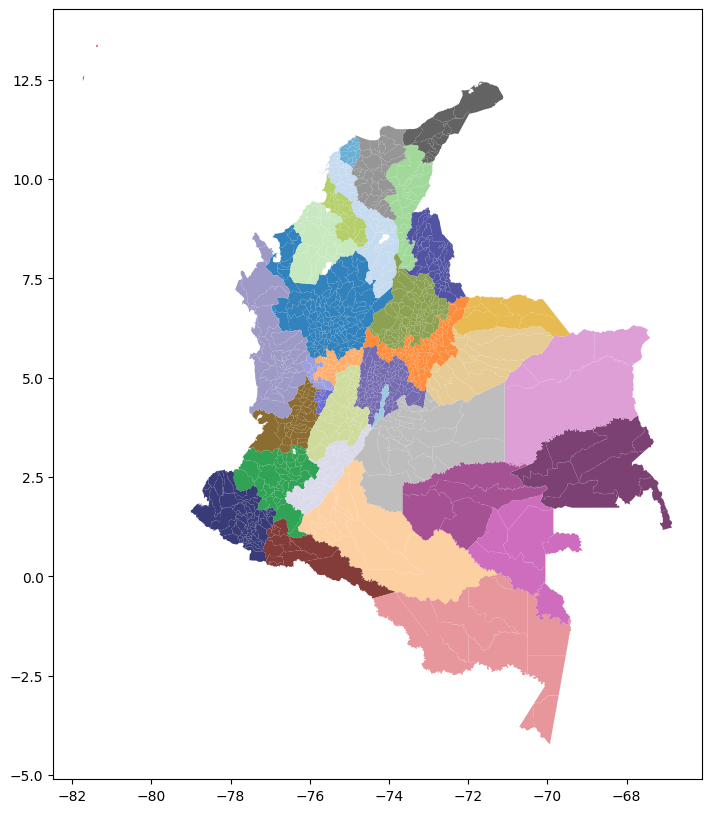

In [ ]:
mpios.plot(figsize=(10,10), cmap=cmap_combined,column='DPTO_CCDGO')

## Validación de los datos de la DIVIPOLA oficial vs el mapa
Se validan los datos oficiales de los códigos de municipio y departamento vs los datos del mapa, para tener una base limpia y confirmada, tanto de los datos tabulares, como de los datos geográficos

### Validación de Departamentos
Cantidad, Nombres
Homogenizar Nombres Y validar existencia

In [ ]:
unique_dpto_mpio = mpios[['DPTO_CCDGO']].drop_duplicates().sort_values(by='DPTO_CCDGO').count()
print(unique_dpto_mpio)

DPTO_CCDGO    33
dtype: int64


In [ ]:
unique_dpto_divipola = divipola_df[['Código Departamento']].drop_duplicates().sort_values(by='Código Departamento').count()
print(unique_dpto_mpio)

DPTO_CCDGO    33
dtype: int64


In [ ]:
unique_dpto_nombre = mpios[['DEPTO','DPTO_CCDGO']].drop_duplicates().sort_values(by='DEPTO')
print(unique_dpto_nombre)

                                        DEPTO DPTO_CCDGO
207                                  AMAZONAS         91
281                                 ANTIOQUIA         05
626                                    ARAUCA         81
463                                 ATLANTICO         08
904                                    BOGOTA         11
486                                   BOLIVAR         13
633                                    BOYACA         15
228                                    CALDAS         17
0                                     CAQUETA         18
188                                  CASANARE         85
16                                      CAUCA         19
528                                     CESAR         20
435                                   CORDOBA         23
756                              CUNDINAMARCA         25
404                                     Choco         27
175                                   GUAINIA         94
224                            

In [ ]:
unique_dpto_divinombre = divipola_df[['Nombre Departamento','Código Departamento']].drop_duplicates().sort_values(by='Nombre Departamento')
print(unique_dpto_divinombre)

                                    Nombre Departamento  Código Departamento
1089                                           AMAZONAS                   91
0                                             ANTIOQUIA                    5
1048                                             ARAUCA                   81
1087  ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANT...                   88
125                                           ATLÁNTICO                    8
148                                        BOGOTÁ, D.C.                   11
149                                             BOLÍVAR                   13
195                                              BOYACÁ                   15
318                                              CALDAS                   17
345                                             CAQUETÁ                   18
1055                                           CASANARE                   85
361                                               CAUCA                   19

In [ ]:
mpios['DPTO_CCDGO'] = pd.to_numeric(mpios['DPTO_CCDGO'], errors='coerce')
mpios.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1118 entries, 0 to 1117
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   DPTO_CCDGO  1118 non-null   int64   
 1   MPIO_CCDGO  1118 non-null   object  
 2   Shape_Leng  1118 non-null   float64 
 3   MPIO_CNMBR  1118 non-null   object  
 4   DESCRPCION  1118 non-null   object  
 5   DEPTO       1118 non-null   object  
 6   P_ENERSI    747 non-null    float64 
 7   P_ENERNO    747 non-null    float64 
 8   P_ALCANSI   1118 non-null   int32   
 9   P_ALCANNO   1118 non-null   int32   
 10  P_ACUESI    1118 non-null   int32   
 11  P_ACUENO    1118 non-null   int32   
 12  P_GASNSI    1118 non-null   int32   
 13  P_GASNNO    1118 non-null   int32   
 14  P_GASNNOIN  1118 non-null   int32   
 15  P_TELEFSI   1118 non-null   int32   
 16  P_TELEFNO   1118 non-null   int32   
 17  P_TELEFNOI  1118 non-null   int32   
 18  ShapeSTAre  1118 non-null   float64 
 19

In [ ]:
print(mpios[['DEPTO','DPTO_CCDGO']].drop_duplicates().sort_values(by='DEPTO'))

                                        DEPTO  DPTO_CCDGO
207                                  AMAZONAS          91
281                                 ANTIOQUIA           5
626                                    ARAUCA          81
463                                 ATLANTICO           8
904                                    BOGOTA          11
486                                   BOLIVAR          13
633                                    BOYACA          15
228                                    CALDAS          17
0                                     CAQUETA          18
188                                  CASANARE          85
16                                      CAUCA          19
528                                     CESAR          20
435                                   CORDOBA          23
756                              CUNDINAMARCA          25
404                                     Choco          27
175                                   GUAINIA          94
224           

## Homogenizar nombres en un dataset
Tomando como base Divipola, se normalizar el nombre en el dataset de mpios, que es el que contiene la informacion geografica, necesaria para hacer algun tipo plot con los datos

In [ ]:
# Create a mapping dictionary from divipola_df (Código Departamento to Nombre Departamento)
# Ensure unique pairs are used to avoid InvalidIndexError
dpto_name_mapping = divipola_df.drop_duplicates(subset=['Código Departamento', 'Nombre Departamento']).set_index('Código Departamento')['Nombre Departamento']

# Apply this mapping to the 'DEPTO' column in mpios based on 'DPTO_CCDGO'
mpios['DEPTO'] = mpios['DPTO_CCDGO'].map(dpto_name_mapping)

# Display unique department names and codes from mpios to verify the update
print(mpios[['DEPTO', 'DPTO_CCDGO']].drop_duplicates().sort_values(by='DPTO_CCDGO'))

                                                  DEPTO  DPTO_CCDGO
281                                           ANTIOQUIA           5
463                                           ATLÁNTICO           8
904                                        BOGOTÁ, D.C.          11
486                                             BOLÍVAR          13
633                                              BOYACÁ          15
228                                              CALDAS          17
0                                               CAQUETÁ          18
16                                                CAUCA          19
528                                               CESAR          20
435                                             CÓRDOBA          23
756                                        CUNDINAMARCA          25
404                                               CHOCÓ          27
934                                               HUILA          41
553                                          LA 

## Comparación de Conteo de Municipios por Departamento

Ahora que los nombres de los departamentos en `mpios` han sido homogeneizados, vamos a contar el número de municipios por departamento en ambos dataframes (`mpios` y `divipola_df`) y compararemos los resultados.

In [ ]:
# Count unique municipalities per department in mpios GeoDataFrame
mpios_municipality_counts = mpios.groupby('DEPTO')['MPIO_CCDGO'].nunique().reset_index()
mpios_municipality_counts.rename(columns={'MPIO_CCDGO': 'Mpios_Count_Map'}, inplace=True)

# Count unique municipalities per department in divipola_df DataFrame
divipola_municipality_counts = divipola_df.groupby('Nombre Departamento')['Código Municipio'].nunique().reset_index()
divipola_municipality_counts.rename(columns={'Código Municipio': 'Mpios_Count_Divipola'}, inplace=True)

# Merge the two counts for comparison
comparison_df = pd.merge(
    mpios_municipality_counts,
    divipola_municipality_counts,
    left_on='DEPTO',
    right_on='Nombre Departamento',
    how='outer'
)

# Drop the redundant 'Nombre Departamento' column and reorder for better readability
comparison_df.drop(columns=['Nombre Departamento'], inplace=True)
comparison_df = comparison_df[['DEPTO', 'Mpios_Count_Map', 'Mpios_Count_Divipola']]

# Display the comparison table, sorting by department name
display(comparison_df.sort_values(by='DEPTO'))

,DEPTO,Mpios_Count_Map,Mpios_Count_Divipola
0,AMAZONAS,11,11
1,ANTIOQUIA,125,125
2,ARAUCA,7,7
3,"ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANT...",2,2
4,ATLÁNTICO,23,23
5,"BOGOTÁ, D.C.",1,1
6,BOLÍVAR,45,46
7,BOYACÁ,123,123
8,CALDAS,27,27
9,CAQUETÁ,16,16


### Departamentos con Discrepancias en el Conteo de Municipios

A continuación, se muestra una tabla con los departamentos donde el número de municipios difiere entre los dos conjuntos de datos (`mpios` y `divipola_df`).

In [ ]:
# Identify departments where municipality counts differ
discrepancy_df = comparison_df[comparison_df['Mpios_Count_Map'] != comparison_df['Mpios_Count_Divipola']]

# Display the departments with discrepancies
display(discrepancy_df.sort_values(by='DEPTO'))

,DEPTO,Mpios_Count_Map,Mpios_Count_Divipola
6,BOLÍVAR,45,46
11,CAUCA,41,42
13,CHOCÓ,30,31
15,CÓRDOBA,28,30
16,GUAINÍA,9,8


In [ ]:
divipola_geo = gpd.read_file('/content/drive/MyDrive/eco2026/DivipolaGeo.gpkg')
divipola_geo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   MpCodigo     1137 non-null   object  
 1   MpNombre     1137 non-null   object  
 2   MpArea       1137 non-null   float64 
 3   MpNorma      407 non-null    object  
 4   MpCategor    1137 non-null   int32   
 5   MpAltitud    1105 non-null   float64 
 6   Restriccion  1105 non-null   object  
 7   Depto        1137 non-null   object  
 8   geometry     1137 non-null   geometry
dtypes: float64(2), geometry(1), int32(1), object(5)
memory usage: 75.6+ KB


In [ ]:
divipola_geo = gpd.read_file('/content/drive/MyDrive/eco2026/DivipolaGeo.gpkg')
divipola_geo['MpCodigo'] = pd.to_numeric(divipola_geo['MpCodigo'], errors='coerce')
divipola_geo.rename(columns={'MpCodigo': 'cod_municipio', 'Depto': 'nombre_depto'}, inplace=True)
divipola_geo['nombre_depto'] = divipola_geo['nombre_depto'].str.upper()

display(divipola_geo.head())

,cod_municipio,MpNombre,MpArea,MpNorma,MpCategor,MpAltitud,Restriccion,nombre_depto,geometry
0,52560,Potosí,388.676332,None,1,2750.0,“No es apropiada su aplicación para la ubicaci...,NARIÑO,"MULTIPOLYGON (((4492613.215 1651194.454, 44926..."
1,86569,Puerto Caicedo,926.789715,Ordenanza No. 012 de 1992,1,272.0,“No es apropiada su aplicación para la ubicaci...,PUTUMAYO,"MULTIPOLYGON (((4614310.436 1654187.702, 46081..."
2,52215,Córdoba,304.917374,Ordenanza No. 39 de 1911,1,2800.0,“No es apropiada su aplicación para la ubicaci...,NARIÑO,"MULTIPOLYGON (((4494252.062 1656970.06, 449422..."
3,52573,Puerres,350.460380,None,1,2800.0,“No es apropiada su aplicación para la ubicaci...,NARIÑO,"MULTIPOLYGON (((4501163.257 1660882.512, 45011..."
4,86320,Orito,1940.661959,Decreto No. 2891 de 1978,1,361.0,“No es apropiada su aplicación para la ubicaci...,PUTUMAYO,"MULTIPOLYGON (((4546705.172 1662279.189, 45466..."


In [ ]:
# Convert 'nombre_depto' in divipola_df_renamed to uppercase for consistent merging
divipola_df_renamed['nombre_depto_upper'] = divipola_df_renamed['nombre_depto'].str.upper()

# Create a mapping DataFrame from divipola_df_renamed for cod_departamento
departamento_code_mapping = divipola_df_renamed[['nombre_depto_upper', 'cod_departamento']].drop_duplicates()

# Merge divipola_geo with the mapping DataFrame
divipola_geo = pd.merge(
    divipola_geo,
    departamento_code_mapping,
    left_on='nombre_depto',
    right_on='nombre_depto_upper',
    how='left'
)

# Drop the auxiliary 'nombre_depto_upper' column from divipola_geo as it's redundant after merge
divipola_geo.drop(columns=['nombre_depto_upper'], inplace=True)

display(divipola_geo.head())

,cod_municipio,MpNombre,MpArea,MpNorma,MpCategor,MpAltitud,Restriccion,nombre_depto,geometry,cod_departamento
0,52560,Potosí,388.676332,None,1,2750.0,“No es apropiada su aplicación para la ubicaci...,NARIÑO,"MULTIPOLYGON (((4492613.215 1651194.454, 44926...",52.0
1,86569,Puerto Caicedo,926.789715,Ordenanza No. 012 de 1992,1,272.0,“No es apropiada su aplicación para la ubicaci...,PUTUMAYO,"MULTIPOLYGON (((4614310.436 1654187.702, 46081...",86.0
2,52215,Córdoba,304.917374,Ordenanza No. 39 de 1911,1,2800.0,“No es apropiada su aplicación para la ubicaci...,NARIÑO,"MULTIPOLYGON (((4494252.062 1656970.06, 449422...",52.0
3,52573,Puerres,350.460380,None,1,2800.0,“No es apropiada su aplicación para la ubicaci...,NARIÑO,"MULTIPOLYGON (((4501163.257 1660882.512, 45011...",52.0
4,86320,Orito,1940.661959,Decreto No. 2891 de 1978,1,361.0,“No es apropiada su aplicación para la ubicaci...,PUTUMAYO,"MULTIPOLYGON (((4546705.172 1662279.189, 45466...",86.0


In [ ]:
municipios_por_departamento_geo = divipola_geo.groupby('nombre_depto')['cod_municipio'].nunique().reset_index()
municipios_por_departamento_geo.rename(columns={'cod_municipio': 'Numero_Municipios'}, inplace=True)

display(municipios_por_departamento_geo.sort_values(by='nombre_depto'))

,nombre_depto,Numero_Municipios
0,AMAZONAS,3
1,ANTIOQUIA,126
2,ARAUCA,8
3,ATLÁNTICO,24
4,BOLÍVAR,47
5,BOYACÁ,124
6,CALDAS,28
7,CAQUETÁ,17
8,CASANARE,20
9,CAUCA,43
